<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-05-25 07:34:25--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.45.118.108
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.45.118.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  11.2MB/s    in 18s     

2026-05-25 07:34:44 (8.35 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [2]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [3]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [4]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [5]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time       None  Apples   
4   Student, full-time       None  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                               None   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [6]:
QUERY = """
SELECT COUNT(*)
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [7]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


In [34]:
QUERY = """
SELECT Frustration, COUNT(*) as count
FROM main
GROUP BY Frustration
ORDER BY COUNT(*)
"""
pd.read_sql_query(QUERY, conn)

,Frustration,count
0,Amount of technical debt;Complexity of tech st...,1
1,Amount of technical debt;Complexity of tech st...,1
2,Amount of technical debt;Complexity of tech st...,1
3,Amount of technical debt;Complexity of tech st...,1
4,Amount of technical debt;Complexity of tech st...,1
...,...,...
950,Amount of technical debt;Complexity of tech st...,666
951,Amount of technical debt;Reliability of tools/...,831
952,Amount of technical debt,2067
953,None of these,2364


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [9]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


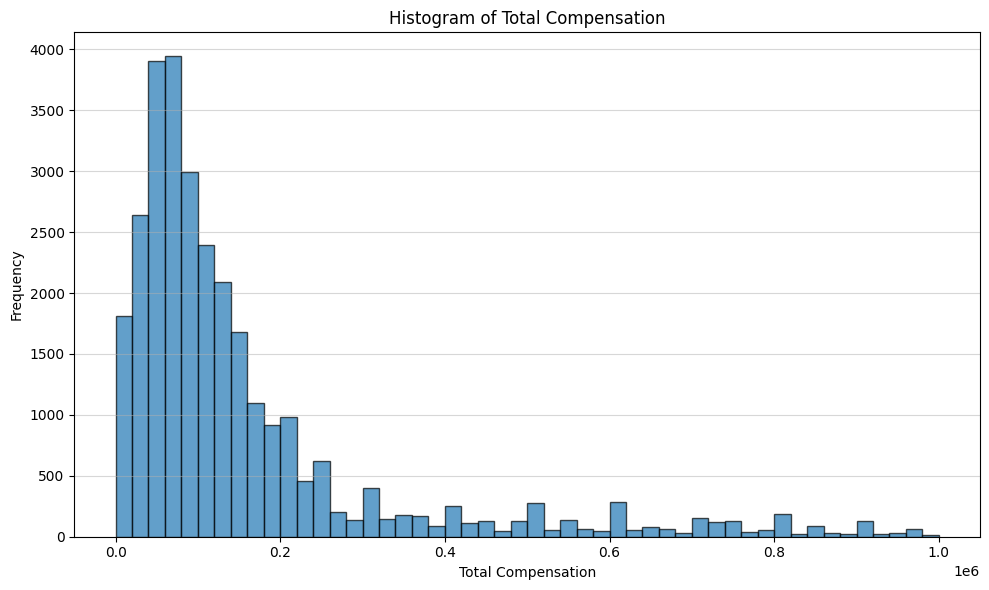

In [10]:
## Write your code here
QUERY = 'SELECT CompTotal FROM main'
df_hist = pd.read_sql_query(QUERY, conn)

# Construct the histogram utilizing matplotlib
plt.figure(figsize=(10, 6))
plt.hist(df_hist[df_hist['CompTotal']< 1_000_000].dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.title('Histogram of Total Compensation')
plt.xlabel('Total Compensation')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

**Box Plots**

Plot a box plot of Age.


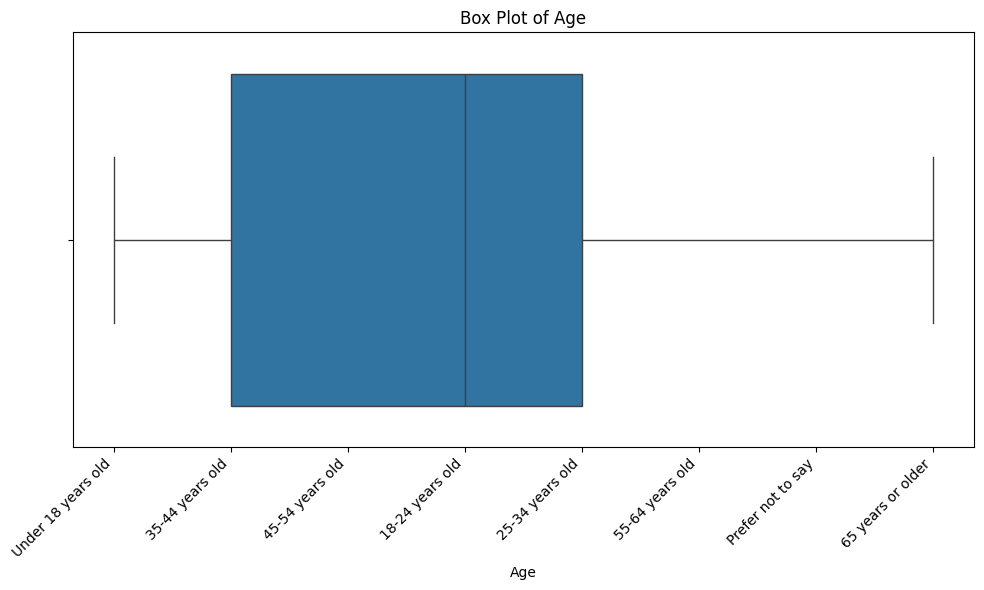

In [12]:
## Write your code here
import seaborn as sns
QUERY = """
SELECT Age
FROM main
WHERE Age IS NOT NULL
"""
df_age = pd.read_sql_query(QUERY, conn)

# Box plot of Age
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_age['Age'])
plt.title('Box Plot of Age')
plt.xlabel('Age')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


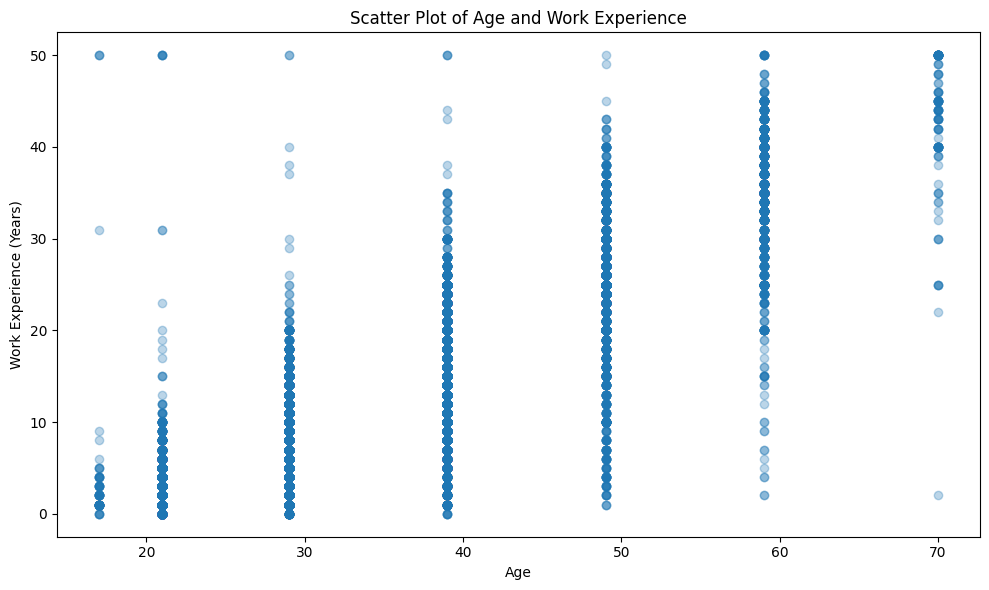

In [14]:
## Write your code here
import seaborn as sns
import matplotlib.pyplot as plt
QUERY = """
SELECT WorkExp
FROM main
WHERE Age IS NOT NULL
"""
df_WorkExp = pd.read_sql_query(QUERY, conn)
# Map Age to numeric
age_mapping = {
    'Under 18 years old': 17, '18-24 years old': 21,
    '25-34 years old': 29, '35-44 years old': 39,
    '45-54 years old': 49, '55-64 years old': 59,
    '65 years or older': 70
}
df_age['Age_numeric'] = df_age['Age'].map(age_mapping)

plt.figure(figsize=(10, 6))
plt.scatter(df_age['Age_numeric'], pd.to_numeric(df_WorkExp['WorkExp'], errors='coerce'), alpha=0.3)
plt.title('Scatter Plot of Age and Work Experience')
plt.xlabel('Age')
plt.ylabel('Work Experience (Years)')
plt.tight_layout()
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


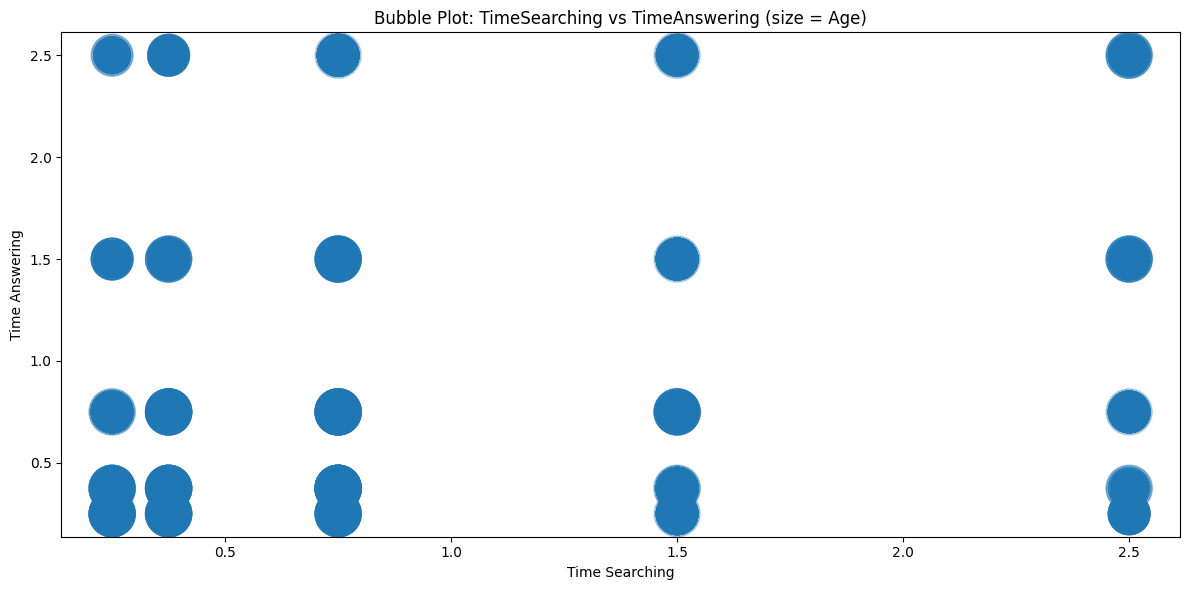

In [19]:
## Write your code here

time_map = {
    'Less than 15 minutes a day': 0.25,
    '15-30 minutes a day': 0.375,
    '30-60 minutes a day': 0.75,
    '60-120 minutes a day': 1.5,
    'Over 120 minutes a day': 2.5
}

age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

df_bubble = pd.read_sql_query("SELECT TimeSearching, TimeAnswering, Age FROM main", conn)
df_bubble['TimeSearching'] = df_bubble['TimeSearching'].map(time_map)
df_bubble['TimeAnswering'] = df_bubble['TimeAnswering'].map(time_map)
df_bubble['Age_numeric'] = df_bubble['Age'].map(age_map)
df_bubble = df_bubble.dropna()

sizes = (df_bubble['Age_numeric'] - df_bubble['Age_numeric'].min() + 1) * 20

plt.figure(figsize=(12, 6))
plt.scatter(df_bubble['TimeSearching'], df_bubble['TimeAnswering'], s=sizes, alpha=0.3)
plt.title('Bubble Plot: TimeSearching vs TimeAnswering (size = Age)')
plt.xlabel('Time Searching')
plt.ylabel('Time Answering')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1539/2686797129.py:34: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



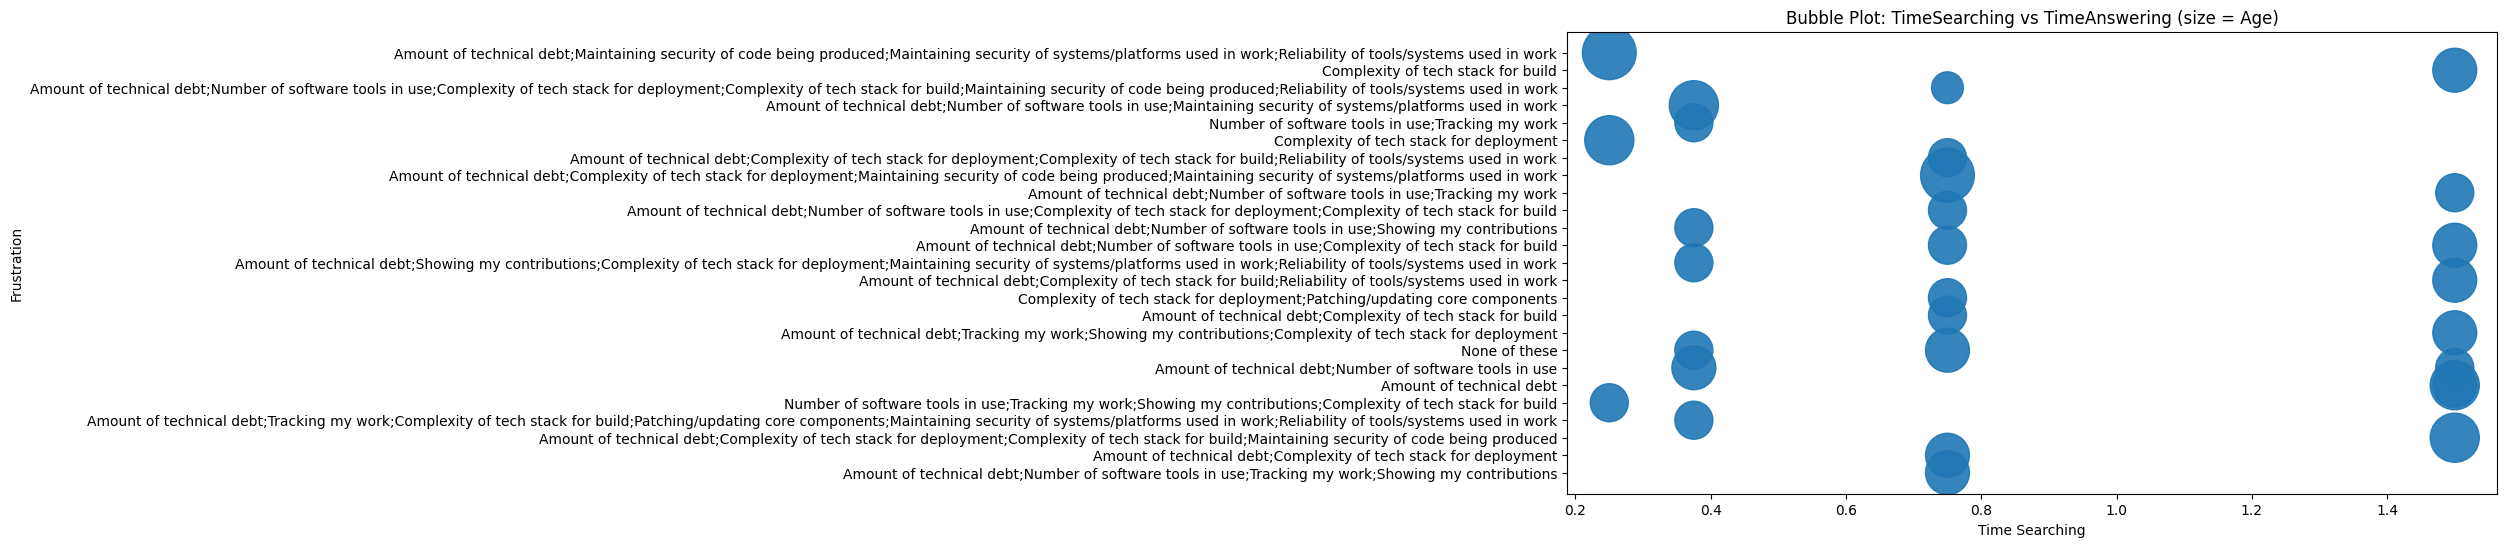

In [61]:
import matplotlib.pyplot as plt

time_map = {
    'Less than 15 minutes a day': 0.25,
    '15-30 minutes a day': 0.375,
    '30-60 minutes a day': 0.75,
    '60-120 minutes a day': 1.5,
    'Over 120 minutes a day': 2.5
}

age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

df_bubble = pd.read_sql_query("SELECT TimeSearching, Frustration, Age FROM main limit 75", conn)
df_bubble['TimeSearching'] = df_bubble['TimeSearching'].map(time_map)
#df_bubble['Frustration'] = df_bubble['TimeAnswering'].map(time_map)
df_bubble['Age_numeric'] = df_bubble['Age'].map(age_map)
df_bubble = df_bubble.dropna()

#sizes = (df_bubble['Age_numeric'] - df_bubble['Age_numeric'].min() + 1) * 20

plt.figure(figsize=(12, 6))
plt.scatter(df_bubble['TimeSearching'], df_bubble['Frustration'], s=df_bubble['Age_numeric']*25, alpha=0.9)
plt.title('Bubble Plot: TimeSearching vs TimeAnswering (size = Age)')
plt.xlabel('Time Searching')
plt.ylabel('Frustration')
plt.tight_layout()
plt.show()

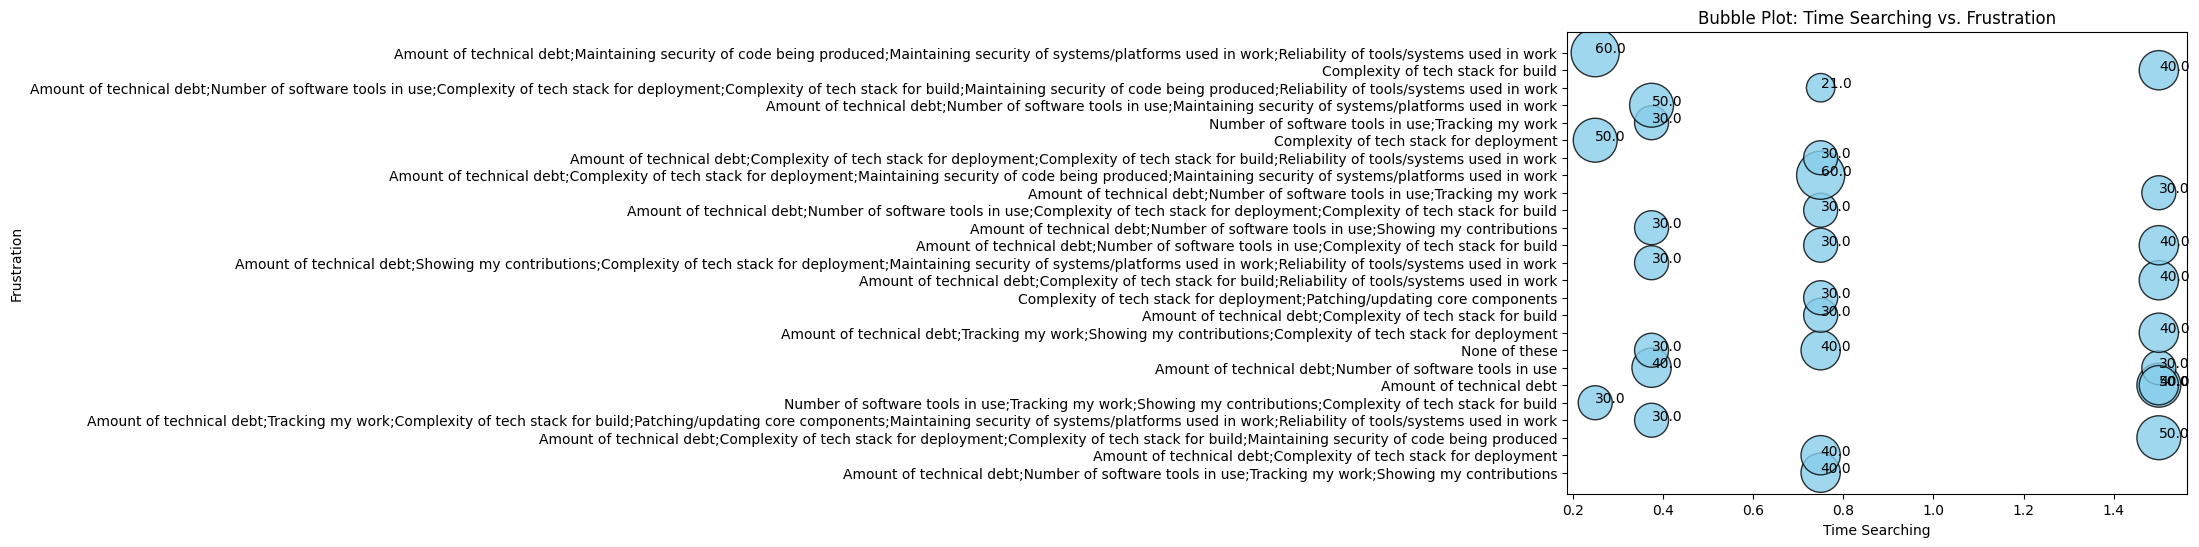

In [64]:
import matplotlib.pyplot as plt
# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    x=df_bubble['TimeSearching'],
    y=df_bubble['Frustration'],
    s=df_bubble['Age_numeric']*20,         # Bubble size mapped to Age
    alpha=0.8,           # Transparency so overlapping bubbles are visible
    c='skyblue',         # Bubble color
    edgecolors='black'
)
for i, row in df_bubble.iterrows():
    ax.text(row['TimeSearching'], row['Frustration'], str(row['Age_numeric']))

#ax.set_yticklabels(['Frustration'])

# Optional: Add axis labels and title
ax.set_xlabel('Time Searching')
ax.set_ylabel('Frustration')
ax.set_title('Bubble Plot: Time Searching vs. Frustration')

plt.show()

In [65]:
import plotly.express as px
#import pandas as pd

fig = px.scatter(
    df_bubble,
    x=df_bubble['TimeSearching'],
    y=df_bubble['Frustration'],
    size=df_bubble['Age_numeric'],
    text=df_bubble['Age_numeric'], # Displays value labels on or near the bubbles
    title='Time Searching vs Frustration by Age',
    size_max=30
)

# Disable Y-axis labels and tick marks
fig.update_yaxes(
    #showticklabels=False,
    tickfont=dict(size=8),
    title_text="" # Hides the axis title
)

# Customize text position for better visibility
#fig.update_traces(textposition='middle center')
fig.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


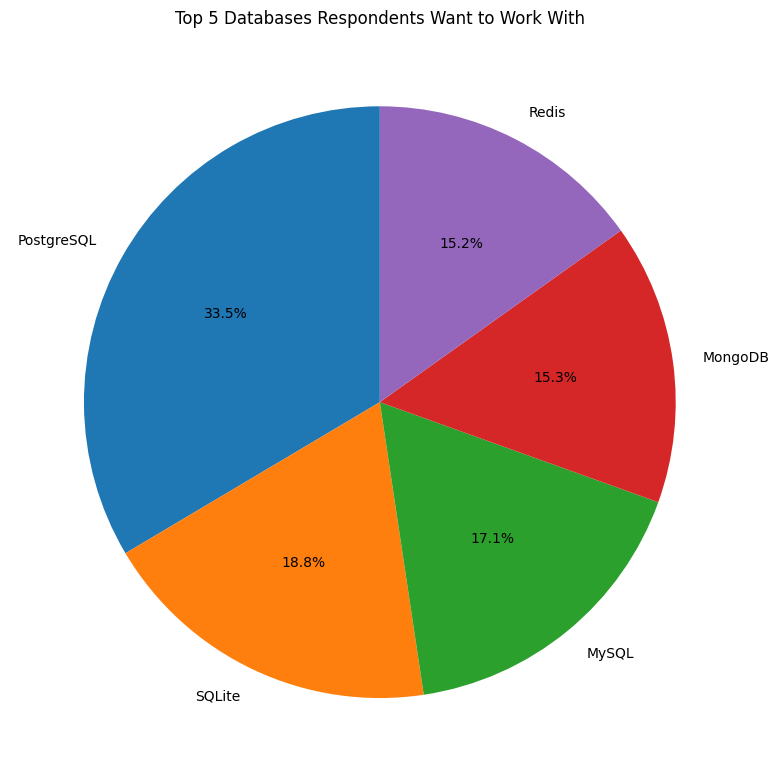

In [66]:
## Write your code here
QUERY = """
SELECT DatabaseWantToWorkWith
FROM main
"""
df_DatabaseWantToWorkWith = pd.read_sql_query(QUERY, conn)
top_db = df_DatabaseWantToWorkWith['DatabaseWantToWorkWith'].str.split(';').explode().value_counts().head(5)

plt.figure(figsize=(8, 8))
top_db.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Top 5 Databases Respondents Want to Work With')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Stacked Charts**

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


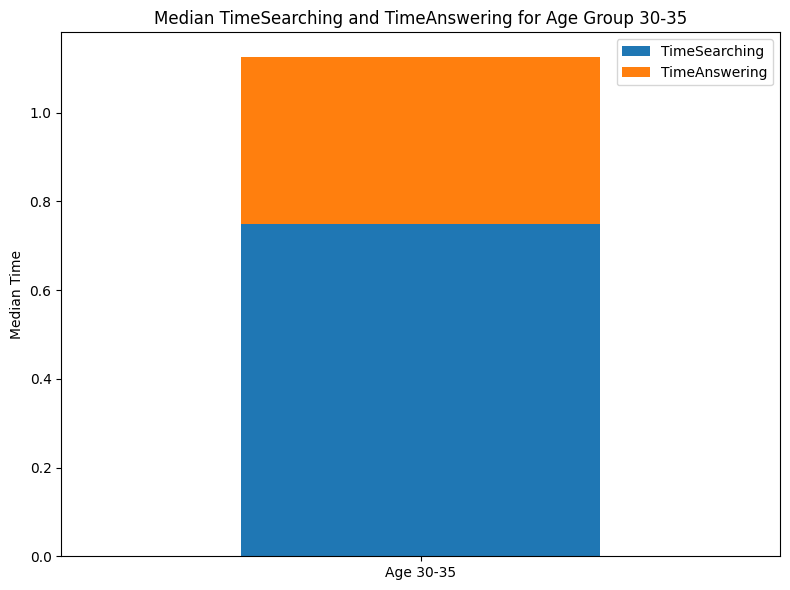

In [67]:
## Write your code here
time_map = {
    'Less than 15 minutes a day': 0.25,
    '15-30 minutes a day': 0.375,
    '30-60 minutes a day': 0.75,
    '60-120 minutes a day': 1.5,
    'Over 120 minutes a day': 2.5
}
df_stack = pd.read_sql_query("SELECT TimeSearching, TimeAnswering, Age FROM main", conn)

df_age = df_stack[df_stack['Age'] == '25-34 years old'].copy()
df_age['TimeSearching'] = df_age['TimeSearching'].map(time_map)
df_age['TimeAnswering'] = df_age['TimeAnswering'].map(time_map)

median_data = pd.DataFrame({
    'TimeSearching': [df_age['TimeSearching'].median()],
    'TimeAnswering': [df_age['TimeAnswering'].median()]
}, index=['Age 30-35'])

median_data.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title('Median TimeSearching and TimeAnswering for Age Group 30-35')
plt.ylabel('Median Time')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


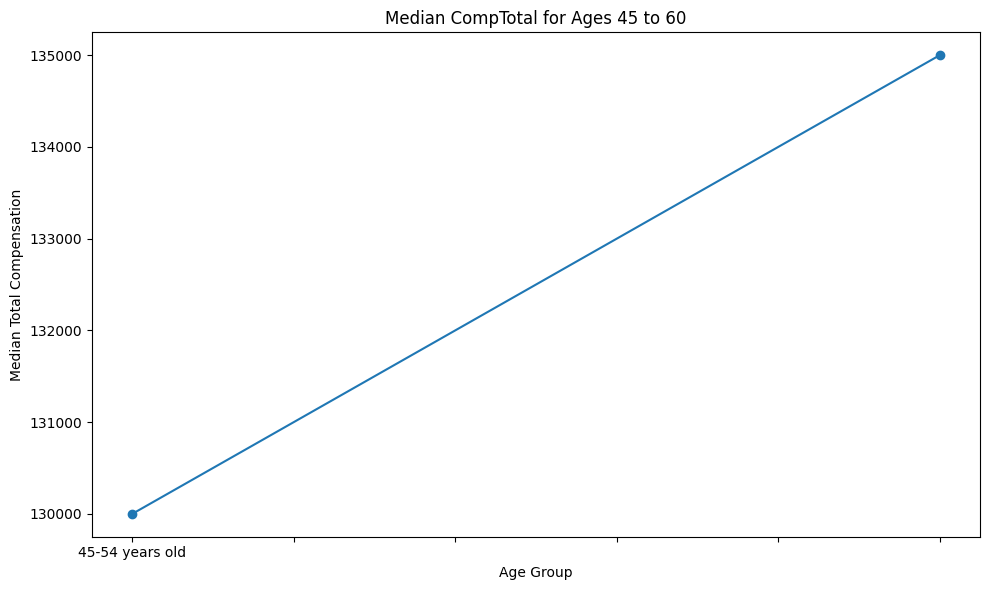

In [68]:
## Write your code here
df_line = pd.read_sql_query("SELECT CompTotal, Age FROM main", conn)
age_filter = ['45-54 years old', '55-64 years old']
df_age = df_line[df_line['Age'].isin(age_filter)].copy()
df_age['CompTotal'] = pd.to_numeric(df_age['CompTotal'], errors='coerce')

median_comp = df_age.groupby('Age')['CompTotal'].median()

median_comp.plot(kind='line', figsize=(10, 6), marker='o')
plt.title('Median CompTotal for Ages 45 to 60')
plt.xlabel('Age Group')
plt.ylabel('Median Total Compensation')
plt.tight_layout()
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


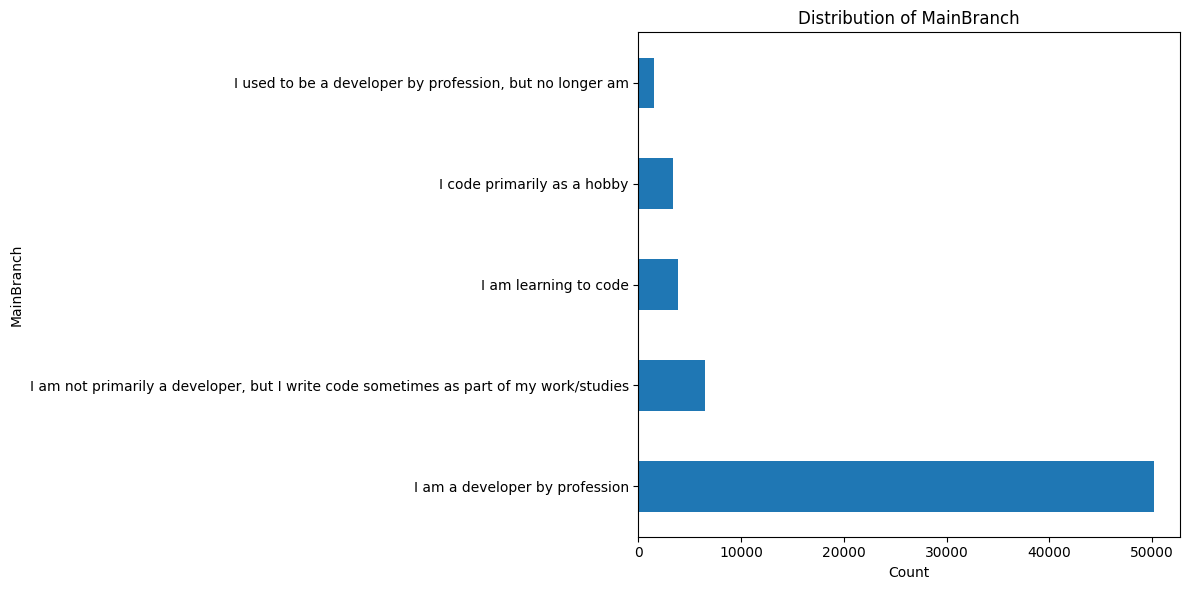

In [69]:
## Write your code here
df_bar = pd.read_sql_query("SELECT MainBranch FROM main", conn)
plt.figure(figsize=(12, 6))
df_bar['MainBranch'].value_counts().plot(kind='barh')
plt.title('Distribution of MainBranch')
plt.xlabel('Count')
plt.ylabel('MainBranch')
plt.tight_layout()
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [ ]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
